In [1]:
# ===================== 1. 导入依赖库 =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

# ===================== 2. 超参数设置 =====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128        # 批次大小
EPOCHS = 25             # 训练轮次
LATENT_DIM = 3          # 潜在空间维度（2维方便可视化，可调整为16/32提升生成效果）
LEARNING_RATE = 1e-3    # 学习率
IMG_SIZE = 28            # MNIST图像尺寸
INPUT_DIM = IMG_SIZE * IMG_SIZE  # 784维输入

# 创建结果保存文件夹
os.makedirs("vae_results", exist_ok=True)
os.makedirs("vae_results/reconstructions", exist_ok=True)
os.makedirs("vae_results/generations", exist_ok=True)

In [2]:
# ===================== 3. 数据集加载 =====================
# 图像预处理：转为张量+归一化到[0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 加载MNIST训练集与测试集
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# 构建DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [3]:
# ===================== 4. VAE模型核心定义 =====================
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # ========== 编码器：将输入映射到潜在空间的分布参数(μ, logσ²) ==========
        # 对应文档：编码器输出分布参数(μ, logσ²)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        # 分别输出均值μ和对数方差logσ²（用logσ²而非σ，保证非负且数值稳定）
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)
        
        # ========== 解码器：从潜在空间采样的向量重建输入图像 ==========
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Sigmoid(),  # 输出归一化到[0,1]，与输入范围匹配
        )

    # 重参数化技巧：解决采样过程不可导的问题
    # 对应文档：重参数化技巧(解决采样不可导问题)
    def reparameterize(self, mu, log_var):
        # 计算标准差σ
        std = torch.exp(0.5 * log_var)
        # 从标准正态分布采样噪声ε
        eps = torch.randn_like(std)
        # 重参数化：z = μ + ε*σ，梯度可回传到μ和σ
        return mu + eps * std

    # 前向传播全流程
    def forward(self, x):
        # 编码器：得到分布参数
        x_encoded = self.encoder(x)
        mu = self.fc_mu(x_encoded)
        log_var = self.fc_log_var(x_encoded)
        
        # 重参数化采样
        z = self.reparameterize(mu, log_var)
        
        # 解码器：重建图像
        x_recon = self.decoder(z)
        
        return x_recon, mu, log_var


# ===================== 5. 损失函数定义 =====================
# 对应文档：损失函数(重建损失+KL散度)
def vae_loss_function(x_recon, x, mu, log_var):
    # 1. 重建损失：衡量输入与重建图像的差异，这里用二元交叉熵BCE
    # 也可使用MSE均方误差，BCE对归一化到[0,1]的像素值更友好
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction="sum")
    
    # 2. KL散度：衡量学到的分布与标准正态分布N(0,1)的差异，闭式解
    # 约束潜在空间的分布，保证生成的连续性与多样性
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    # 总损失 = 重建损失 + KL散度
    total_loss = recon_loss + kl_loss
    
    return total_loss, recon_loss, kl_loss

In [4]:
# ===================== 6. 模型与优化器初始化 =====================
model = VAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ===================== 7. 训练循环 =====================
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_train_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    # 遍历训练集
    for batch_idx, (imgs, _) in enumerate(tqdm(dataloader, desc="训练中")):
        # 展平图像：[B,1,28,28] -> [B,784]
        imgs = imgs.view(-1, INPUT_DIM).to(device)
        
        # 前向传播
        imgs_recon, mu, log_var = model(imgs)
        
        # 计算损失
        loss, recon_loss, kl_loss = vae_loss_function(imgs_recon, imgs, mu, log_var)
        
        # 反向传播与参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 累计损失
        total_train_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()
    
    # 计算平均损失
    avg_loss = total_train_loss / len(dataloader.dataset)
    avg_recon = total_recon_loss / len(dataloader.dataset)
    avg_kl = total_kl_loss / len(dataloader.dataset)
    
    return avg_loss, avg_recon, avg_kl

# 测试/验证循环
def test_epoch(model, dataloader, device, epoch):
    model.eval()
    total_test_loss = 0
    
    with torch.no_grad():
        for batch_idx, (imgs, _) in enumerate(dataloader):
            imgs = imgs.view(-1, INPUT_DIM).to(device)
            imgs_recon, mu, log_var = model(imgs)
            loss, _, _ = vae_loss_function(imgs_recon, imgs, mu, log_var)
            total_test_loss += loss.item()
            
            # 保存第一个批次的重建结果，用于可视化
            if batch_idx == 0:
                n = 8
                # 拼接原图与重建图
                comparison = torch.cat([
                    imgs.view(-1, 1, IMG_SIZE, IMG_SIZE)[:n],
                    imgs_recon.view(-1, 1, IMG_SIZE, IMG_SIZE)[:n]
                ])
                save_image(
                    comparison.cpu(),
                    f"vae_results/reconstructions/epoch_{epoch+1}.png",
                    nrow=n,
                    normalize=True
                )
    
    avg_test_loss = total_test_loss / len(dataloader.dataset)
    return avg_test_loss

# 启动全流程训练
print(f"使用设备: {DEVICE}")
train_loss_list = []
test_loss_list = []

for epoch in range(EPOCHS):
    print(f"\n===== 第 {epoch+1}/{EPOCHS} 轮训练 =====")
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, DEVICE)
    test_loss = test_epoch(model, test_loader, DEVICE, epoch)
    
    # 记录损失
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)
    
    # 打印日志
    print(f"训练平均损失: {train_loss:.4f} | 重建损失: {train_recon:.4f} | KL散度: {train_kl:.4f}")
    print(f"测试平均损失: {test_loss:.4f}")
    
    # 每5轮生成一次全新的手写数字
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            # 从标准正态分布采样潜在向量z
            z = torch.randn(64, LATENT_DIM).to(DEVICE)
            # 解码器生成图像
            gen_imgs = model.decoder(z).view(-1, 1, IMG_SIZE, IMG_SIZE)
            # 保存生成结果
            save_image(
                gen_imgs.cpu(),
                f"vae_results/generations/epoch_{epoch+1}.png",
                nrow=8,
                normalize=True
            )

# 保存最终模型
torch.save(model.state_dict(), "vae_results/vae_mnist_final.pth")
print("\n训练完成！模型与结果已保存至 vae_results 文件夹")

使用设备: cuda

===== 第 1/25 轮训练 =====


训练中: 100%|████████████████████████████████████████████████████████████████████████| 469/469 [00:04<00:00, 107.57it/s]


训练平均损失: 175.9199 | 重建损失: 170.6152 | KL散度: 5.3047
测试平均损失: 150.9755

===== 第 2/25 轮训练 =====


训练中: 100%|████████████████████████████████████████████████████████████████████████| 469/469 [00:03<00:00, 129.99it/s]


训练平均损失: 147.3942 | 重建损失: 140.1644 | KL散度: 7.2298
测试平均损失: 144.1686

===== 第 3/25 轮训练 =====


...

训练平均损失: 126.7401 | 重建损失: 117.8688 | KL散度: 8.8713
测试平均损失: 129.7586

===== 第 24/25 轮训练 =====


训练中: 100%|████████████████████████████████████████████████████████████████████████| 469/469 [00:03<00:00, 124.69it/s]


训练平均损失: 126.5358 | 重建损失: 117.6567 | KL散度: 8.8791
测试平均损失: 129.7729

===== 第 25/25 轮训练 =====


训练中: 100%|████████████████████████████████████████████████████████████████████████| 469/469 [00:01<00:00, 345.90it/s]


训练平均损失: 126.2724 | 重建损失: 117.3665 | KL散度: 8.9059
测试平均损失: 129.8201

训练完成！模型与结果已保存至 vae_results 文件夹


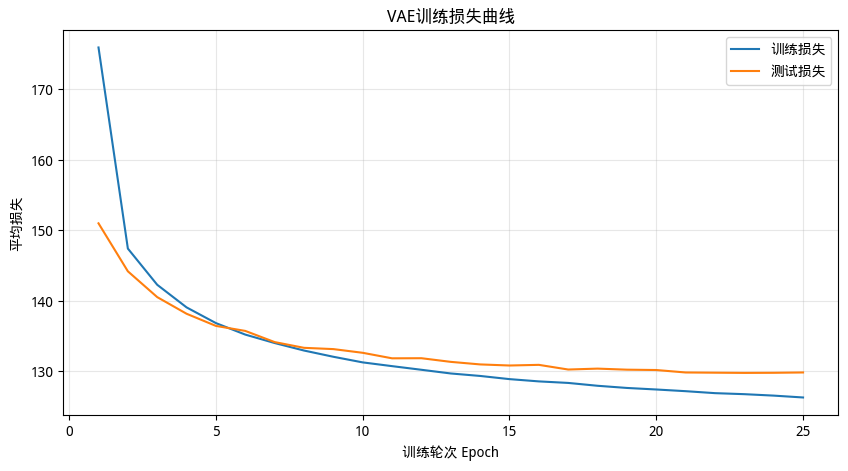

In [5]:
# ===================== 8. 结果可视化 =====================
# 8.1 损失曲线绘制
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_loss_list, label="训练损失")
plt.plot(range(1, EPOCHS+1), test_loss_list, label="测试损失")
plt.xlabel("训练轮次 Epoch")
plt.ylabel("平均损失")
plt.title("VAE训练损失曲线")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("vae_results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# 8.2 潜在空间可视化（仅当LATENT_DIM=2时生效）
if LATENT_DIM == 2:
    model.eval()
    latent_vectors = []
    labels = []
    
    with torch.no_grad():
        for imgs, label in test_loader:
            imgs = imgs.view(-1, INPUT_DIM).to(DEVICE)
            x_encoded = model.encoder(imgs)
            mu = model.fc_mu(x_encoded)
            latent_vectors.append(mu.cpu().numpy())
            labels.append(label.numpy())
    
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    # 绘制潜在空间散点图
    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        latent_vectors[:, 0], latent_vectors[:, 1],
        c=labels, cmap="tab10", s=2, alpha=0.8
    )
    plt.colorbar(scatter, ticks=range(10), label="数字类别")
    plt.xlabel("潜在维度 1")
    plt.ylabel("潜在维度 2")
    plt.title("VAE 2维潜在空间分布（MNIST测试集）")
    plt.grid(True, alpha=0.3)
    plt.savefig("vae_results/latent_space.png", dpi=300, bbox_inches="tight")
    plt.show()

In [7]:
# 8.3 生成效果展示：加载最终模型生成新样本
if LATENT_DIM == 2:
    print("\n===== 加载最终模型生成全新手写数字 =====")
    model.load_state_dict(torch.load("vae_results/vae_mnist_final.pth", map_location=DEVICE))
    model.eval()
    
    with torch.no_grad():
        z = torch.randn(100, LATENT_DIM).to(DEVICE)
        final_gen = model.decoder(z).view(-1, 1, IMG_SIZE, IMG_SIZE)
        grid = make_grid(final_gen.cpu(), nrow=10, normalize=True)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title("VAE最终生成的手写数字")
        plt.savefig("vae_results/final_generation.png", dpi=300, bbox_inches="tight")
        plt.show()
    
        manual_coords = [-0.1, 0]  
        z_manual = torch.tensor([manual_coords], dtype=torch.float32).to(DEVICE)
        final_gen_x = model.decoder(z_manual).view(-1, 1, IMG_SIZE, IMG_SIZE)
        
        plt.figure(figsize=(4,4))
        plt.imshow(final_gen_x.cpu().squeeze())
        plt.axis("off")
        plt.title(f"潜在空间坐标: {manual_coords}")
        plt.show()

===== 绘制3D潜在空间分布图 =====


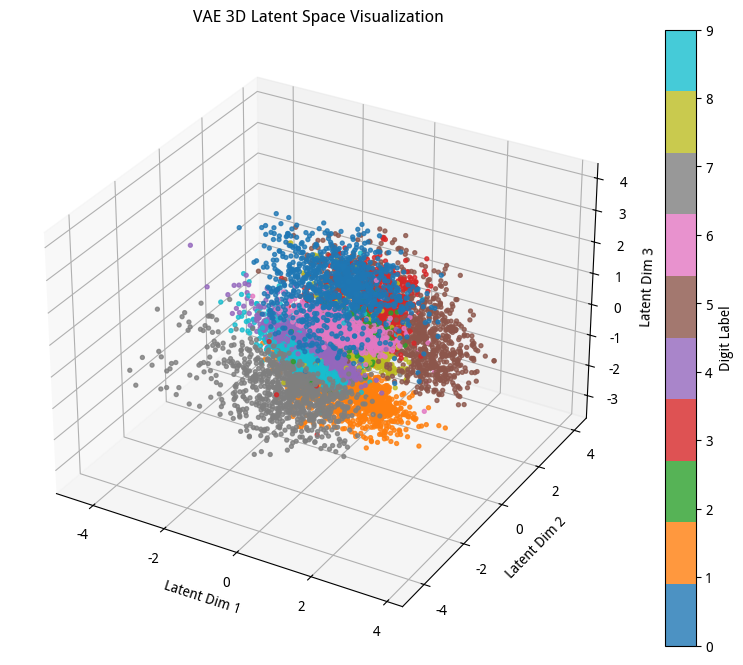

In [8]:
#三维潜在空间绘图
if LATENT_DIM == 3:
    import matplotlib.pyplot as plt
    # 导入3D绘图工具包
    from mpl_toolkits.mplot3d import Axes3D
    
    def plot_latent_3d(model, dataloader, device):
        # 1. 初始化3D画布
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # 2. 提取所有数据的3维潜在向量z和标签
        z_list = []
        label_list = []
        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(device)
                # 编码器输出3维 mu
                h = model.encoder(x.view(-1, 784))
                mu = model.fc_mu(h)
                z_list.append(mu.cpu().numpy())
                label_list.append(y.numpy())
        
        z_all = np.concatenate(z_list, axis=0)
        labels = np.concatenate(label_list, axis=0)
        
        # 3. 绘制3D散点图（按数字分类上色）
        scatter = ax.scatter(
            z_all[:, 0],  # x轴：潜在空间第1维
            z_all[:, 1],  # y轴：潜在空间第2维
            z_all[:, 2],  # z轴：潜在空间第3维
            c=labels, cmap='tab10', s=8, alpha=0.8
        )
        ax.set_xlabel('Latent Dim 1')
        ax.set_ylabel('Latent Dim 2')
        ax.set_zlabel('Latent Dim 3')
        plt.colorbar(scatter, ticks=range(10), label='Digit Label')
        plt.title('VAE 3D Latent Space Visualization')
        plt.savefig("vae_results/latent_space_3D.png", dpi=300, bbox_inches="tight")
        plt.show()

    print("===== 绘制3D潜在空间分布图 =====")
    plot_latent_3d(model, test_loader, DEVICE)

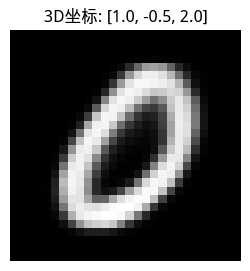

In [9]:
# 手动指定3维潜在空间坐标生成数字
if LATENT_DIM == 3:
    with torch.no_grad():
        # 手动输入3维坐标 (x,y,z)，范围推荐 [-3, 3]
        manual_coords = [1.0, -0.5, 2.0]  
        z_manual = torch.tensor([manual_coords], dtype=torch.float32).to(DEVICE)
        gen_img = model.decoder(z_manual).view(IMG_SIZE, IMG_SIZE)
        
        plt.figure(figsize=(3,3))
        plt.imshow(gen_img.cpu(), cmap='gray')
        plt.axis('off')
        plt.title(f'3D坐标: {manual_coords}')
        plt.show()

===== 绘制Plotly交互式3D潜在空间分布图 =====


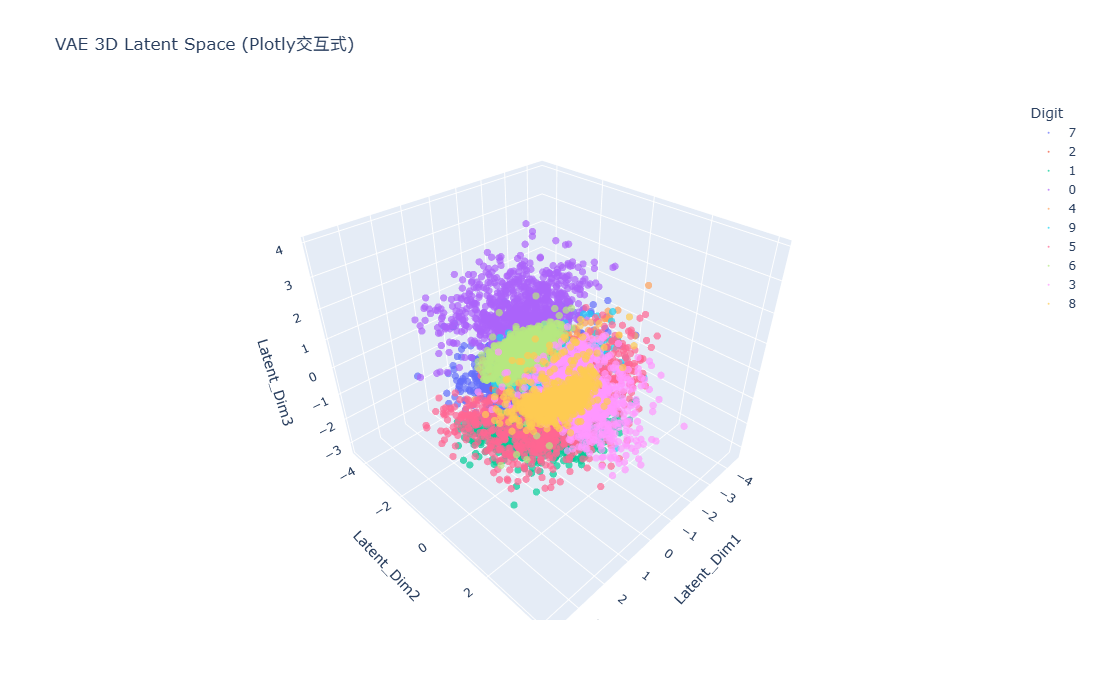

In [21]:
# 三维潜在空间交互式绘图（Plotly版）
if LATENT_DIM == 3:
    import plotly.express as px
    import pandas as pd
    
    def plot_latent_plotly_3d(model, dataloader, device):
        # 1. 核心逻辑：和matplotlib完全一致！提取所有数据的3维潜在向量z和标签
        z_list = []
        label_list = []
        # 关闭梯度计算（推理模式，提速省显存）
        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(device)
                # 编码器前向传播 → 输出3维均值mu
                h = model.encoder(x.view(-1, 784))
                mu = model.fc_mu(h)
                # 保存到CPU，转为numpy数组
                z_list.append(mu.cpu().numpy())
                label_list.append(y.numpy())
        
        # 2. 拼接所有数据（和matplotlib完全一样）
        z_all = np.concatenate(z_list, axis=0)
        labels = np.concatenate(label_list, axis=0)
        
        # 3. 构建DataFrame（Plotly专用数据格式）
        df = pd.DataFrame({
            "Latent_Dim1": z_all[:, 0],
            "Latent_Dim2": z_all[:, 1],
            "Latent_Dim3": z_all[:, 2],
            "Digit": labels.astype(str)  # 标签转字符串，方便区分颜色
        })
        
        # 4. 绘制交互式3D散点图（核心替换部分）
        fig = px.scatter_3d(
            df,
            x="Latent_Dim1", y="Latent_Dim2", z="Latent_Dim3",
            color="Digit",          # 按手写数字标签上色
            opacity=0.7,            # 透明度
            title="VAE 3D Latent Space (Plotly交互式)",
        )
        fig.update_traces(marker=dict(size=2))
        # 调整布局
        fig.update_layout(height=700)
        # 自动打开浏览器展示交互式图表
        fig.show()

    # ===================== 调用函数（和matplotlib调用方式完全一样） =====================
    print("===== 绘制Plotly交互式3D潜在空间分布图 =====")
    plot_latent_plotly_3d(model, test_loader, DEVICE)